**Task No 1:  Exploring and Visualizing a Simple Dataset**

In [ ]:
import pandas as pd
dataset = pd.read_csv('/content/iris_dataset.csv')
dataset.shape

(150, 5)

In [ ]:
#Info and Describe Summary Statistics
dataset.info()
print('Printing the Describe functuion')
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
Printing the Describe functuion


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


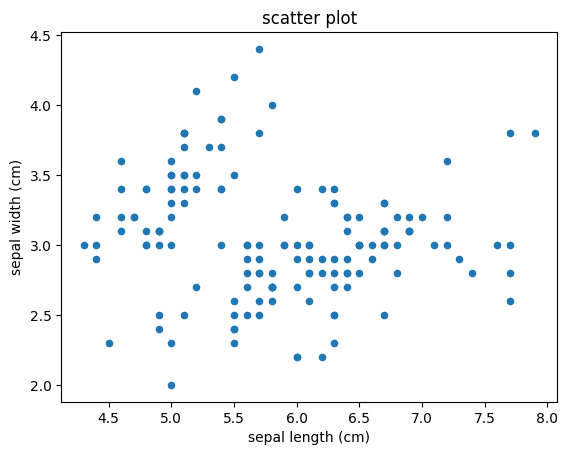

In [ ]:
# Visualizing the dataset
import matplotlib.pyplot as plt
# Scatte Plot
dataset.plot( title = 'scatter plot', kind='scatter', x='sepal length (cm)', y='sepal width (cm)')
plt.show()

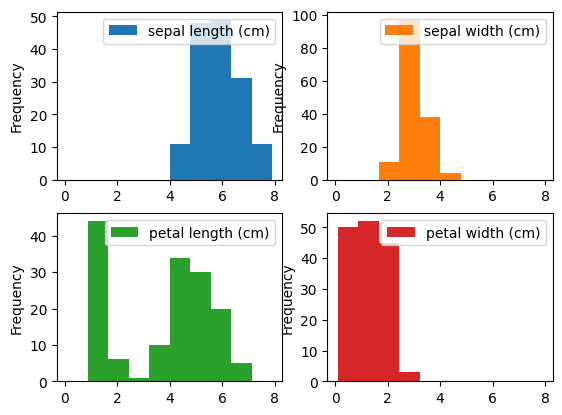

In [ ]:
# Plotting the histogram
dataset.plot(kind='hist', subplots=True, layout=(2,2), sharex=False)
plt.show()

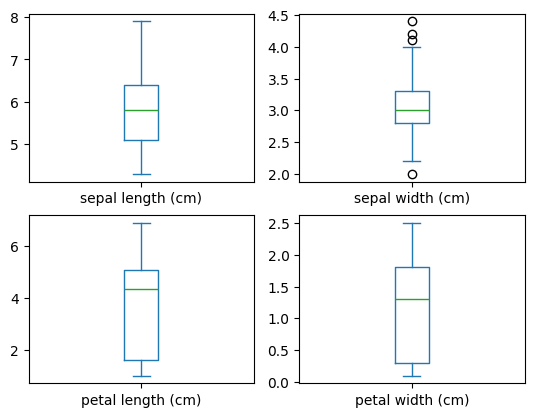

In [ ]:
# Box plot to identify outliers
dataset.plot(kind='box', subplots=True, layout=(2,2), sharex=False)
plt.show()

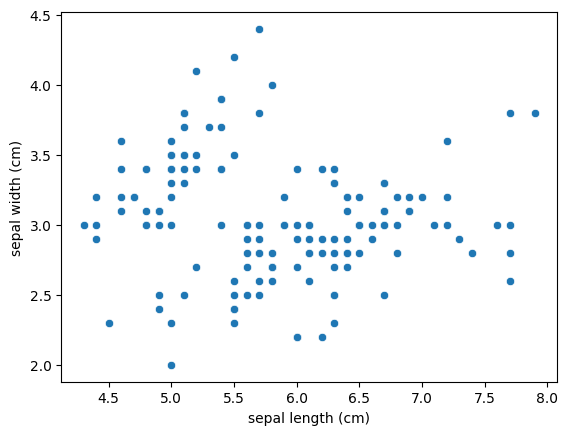

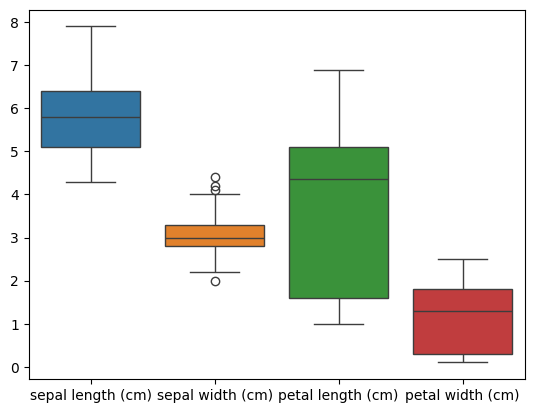

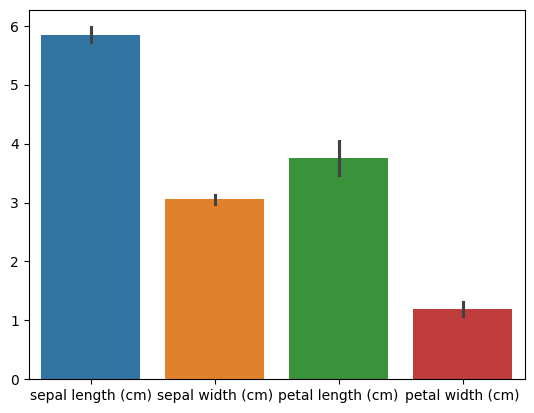

In [ ]:
# Plotting scatter, bar and box uisng seaborn
import seaborn as sns
sns.scatterplot(data=dataset, x='sepal length (cm)', y='sepal width (cm)')
plt.show()
sns.boxplot(data=dataset)
plt.show()
sns.barplot(data=dataset)
plt.show()

**Task No 2:  Predict Future Stock Prices (Short-Term)**

/tmp/ipykernel_16115/2087180689.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Successfully downloaded 1255 rows of data.

Training data size: 1003
Testing data size: 251

Model Evaluation:
  Mean Squared Error (MSE): 13.37
  R-squared (R2): 0.99


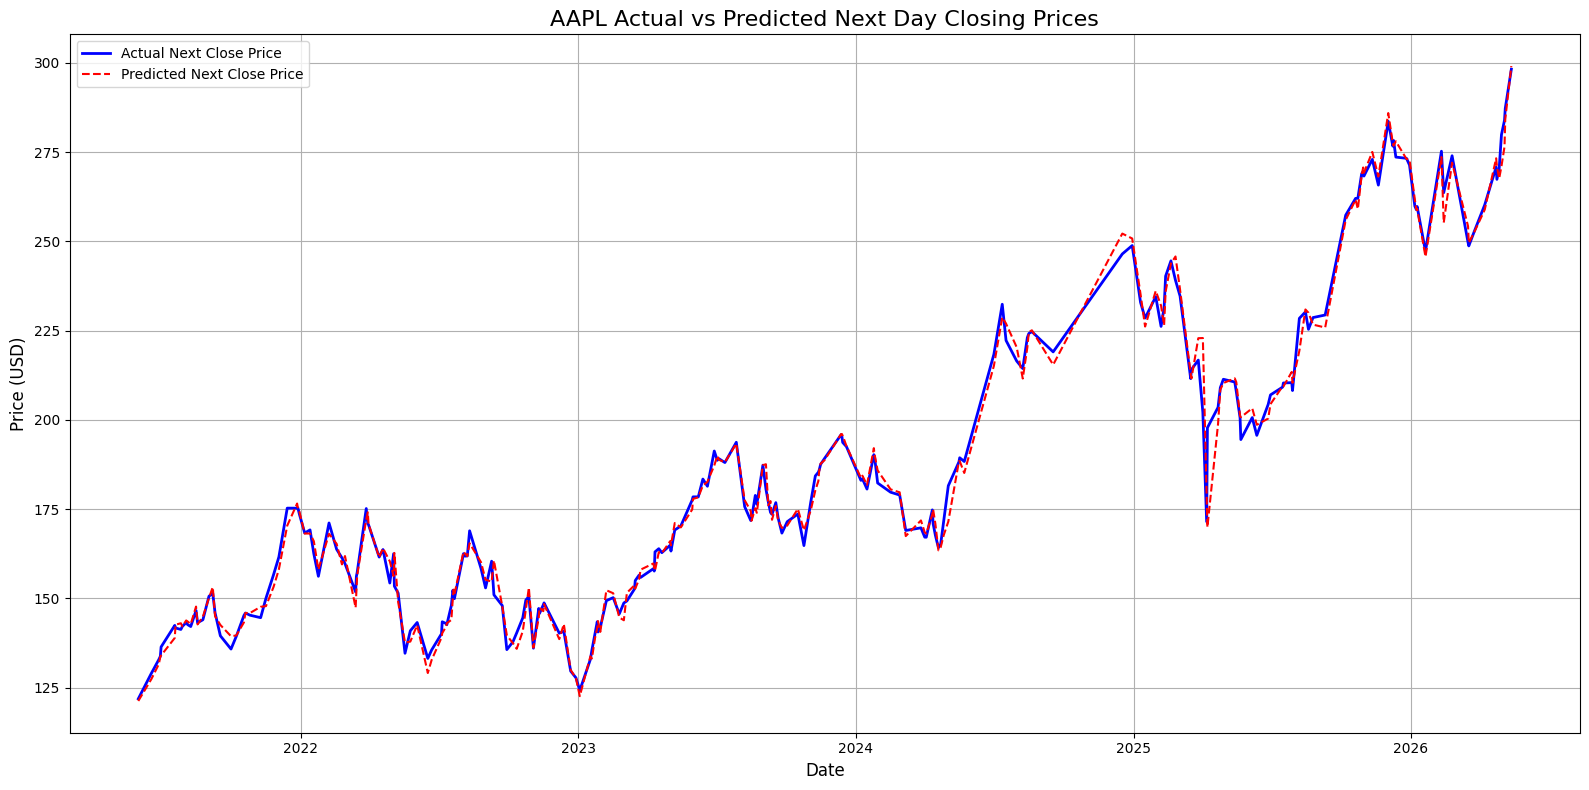

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Select a stock (e.g., Apple, Tesla).
ticker = 'AAPL'  # Apple Inc.

# Define date range for historical data
end_date = pd.to_datetime('today')
start_date = end_date - pd.DateOffset(years=5)

# 2. Load historical data using the yfinance library.
print(f"Downloading historical data for {ticker} from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}...")
stock_data = yf.download(ticker, start=start_date, end=end_date)

if stock_data.empty:
    print(f"Could not download data for {ticker}. Please check the ticker symbol or internet connection.")
else:
    print(f"Successfully downloaded {len(stock_data)} rows of data.")

    # 3. Use features like Open, High, Low, and Volume to predict the next Close price.
    # Create the target variable: next day's closing price
    # Shift 'Close' price by -1 to get the next day's closing price
    stock_data['Next_Close'] = stock_data['Close'].shift(-1)

    # Drop the last row as it will have NaN for 'Next_Close' (no next day to predict for the last day)
    stock_data.dropna(inplace=True)

    # Define features (X) and target (y)
    features = ['Open', 'High', 'Low', 'Volume', 'Close'] # 'Close' from current day is a strong predictor
    X = stock_data[features]
    y = stock_data['Next_Close']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"\nTraining data size: {len(X_train)}")
    print(f"Testing data size: {len(X_test)}")

    # 4. Train a Linear Regression or Random Forest model.
    # Using Linear Regression for this example
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\nModel Evaluation:")
    print(f"  Mean Squared Error (MSE): {mse:.2f}")
    print(f"  R-squared (R2): {r2:.2f}")

    # 5. Plot actual vs predicted closing prices for comparison.
    # Create a DataFrame for plotting, aligning actual and predicted values by index
    plot_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
    plot_df = plot_df.sort_index()

    plt.figure(figsize=(16, 8))
    plt.plot(plot_df.index, plot_df['Actual'], label='Actual Next Close Price', color='blue', linewidth=2)
    plt.plot(plot_df.index, plot_df['Predicted'], label='Predicted Next Close Price', color='red', linestyle='--', linewidth=1.5)
    plt.title(f'{ticker} Actual vs Predicted Next Day Closing Prices', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Dataset loaded successfully.
Dataset shape: (303, 14)
First 5 rows of the dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Checking for missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>

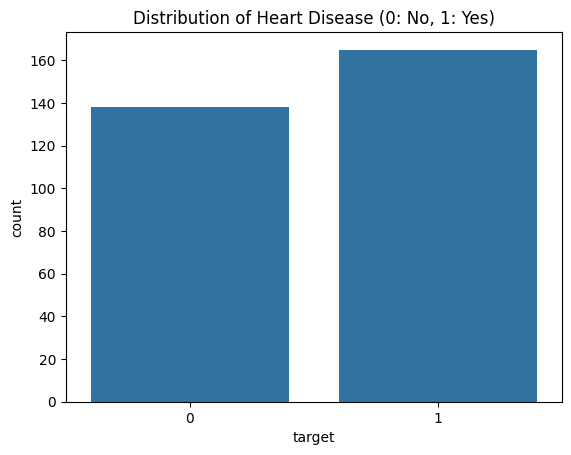


Correlation Matrix (Heatmap):


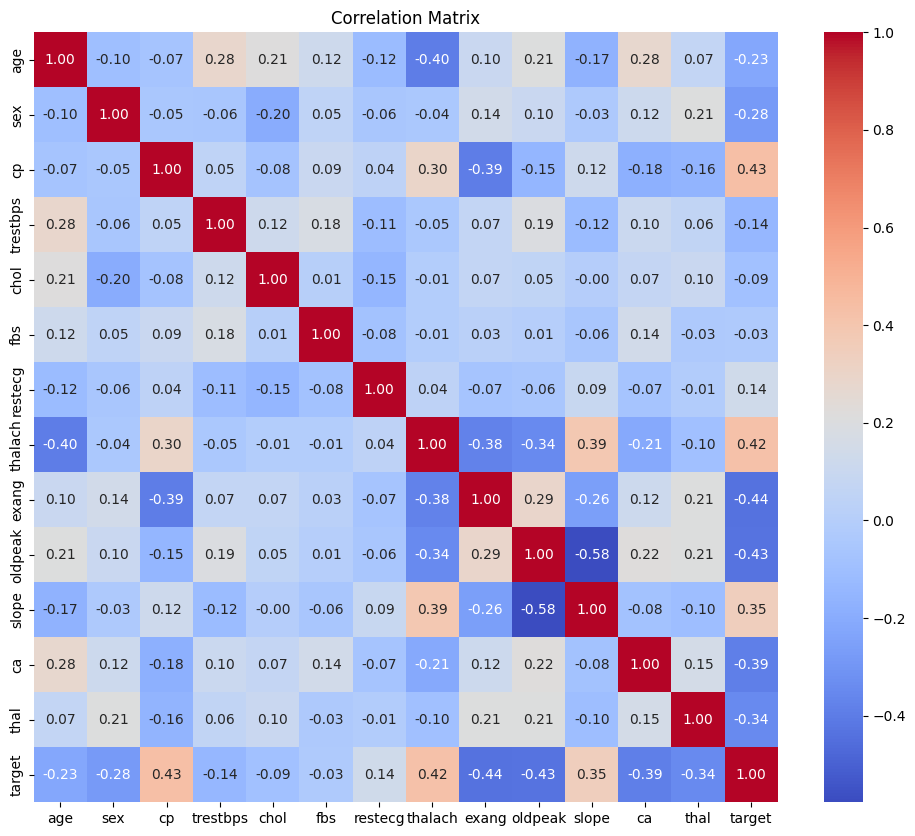

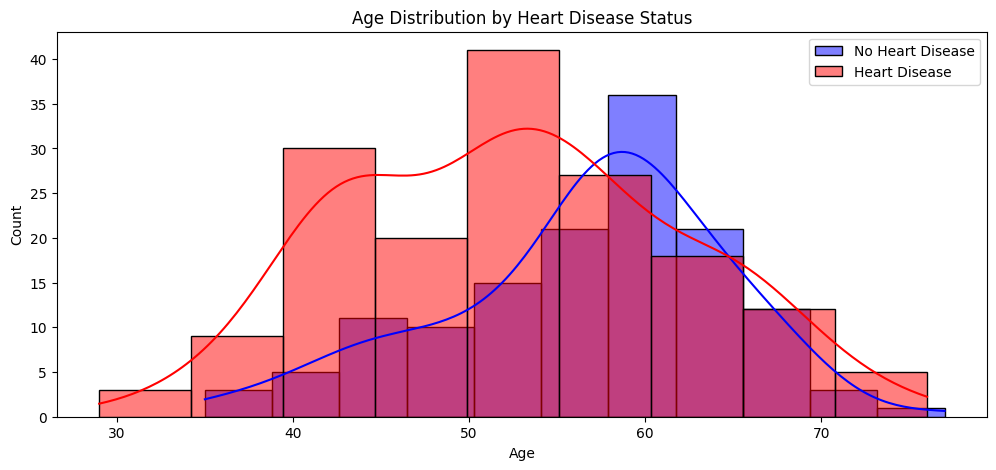


Training data size: 242 samples
Testing data size: 61 samples
Logistic Regression model trained successfully.

Accuracy Score: 0.8033

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61


Confusion Matrix:
[[19  9]
 [ 3 30]]


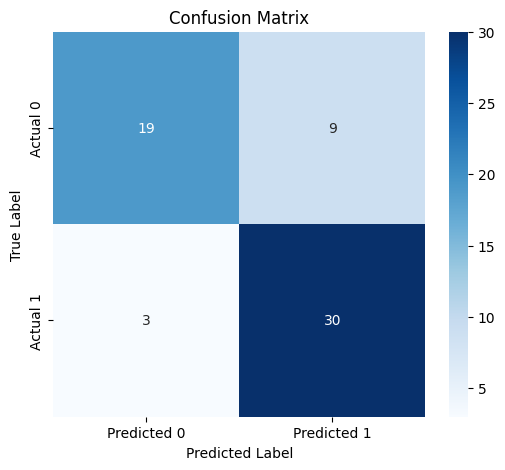


ROC AUC Score: 0.8690


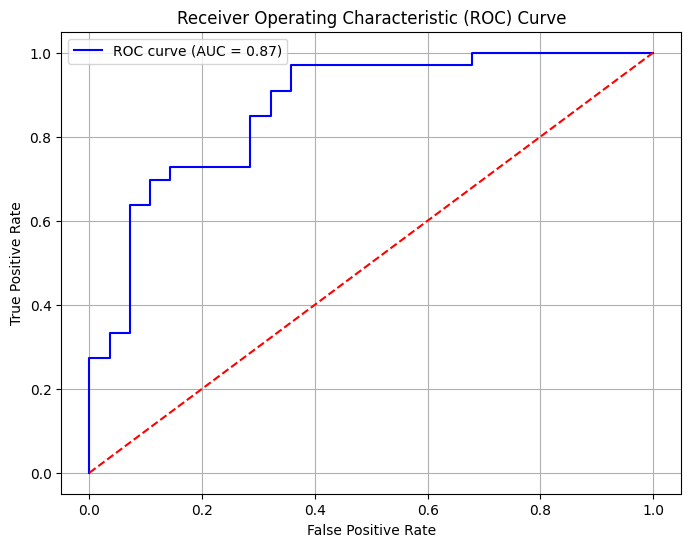


Top Important Features (by absolute coefficient value):
     Feature  Coefficient
2         cp     0.957943
1        sex    -0.710668
12      thal    -0.628191
9    oldpeak    -0.575532
7    thalach     0.558192
11        ca    -0.549026
4       chol    -0.492161
8      exang    -0.472309
10     slope     0.305326
6    restecg     0.233569
3   trestbps    -0.206116
5        fbs    -0.064277
0        age     0.015949


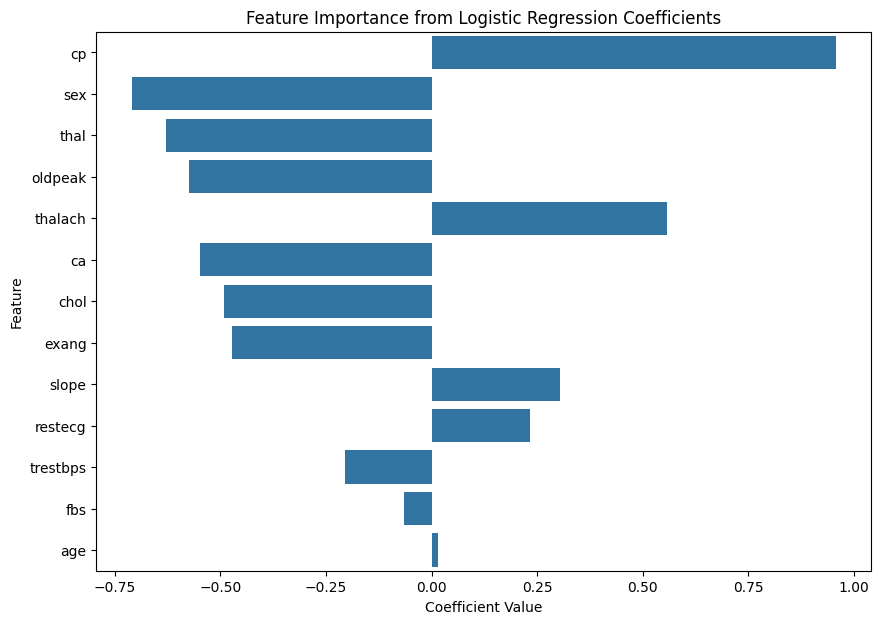

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler

# --- 1. Load the Dataset ---
# Assuming 'heart.csv' is available in the current directory or '/content/'
# If you don't have the file, you can download it from Kaggle's Heart Disease UCI Dataset:
# https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data
try:
    df = pd.read_csv('heart.csv')
    print("Dataset loaded successfully.")
    print(f"Dataset shape: {df.shape}")
    print("First 5 rows of the dataset:")
    print(df.head())
except FileNotFoundError:
    print("Error: 'heart.csv' not found. Please upload the dataset or provide the correct path.")
    print("You can download the Heart Disease UCI Dataset from Kaggle: https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data")
    exit()

# --- 2. Clean the Dataset (Handle Missing Values) ---
print("\nChecking for missing values:")
print(df.isnull().sum())
# No missing values usually in this dataset, but this step is good practice.

# --- 3. Perform Exploratory Data Analysis (EDA) ---
print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print("\nDistribution of Target Variable (Heart Disease):")
print(df['target'].value_counts())
sns.countplot(x='target', data=df)
plt.title('Distribution of Heart Disease (0: No, 1: Yes)')
plt.show()

print("\nCorrelation Matrix (Heatmap):")
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Example: Distribution of 'age' and its relation to 'target'
plt.figure(figsize=(12, 5))
sns.histplot(df[df['target'] == 0]['age'], color='blue', label='No Heart Disease', kde=True)
sns.histplot(df[df['target'] == 1]['age'], color='red', label='Heart Disease', kde=True)
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

# --- 4. Train a Classification Model (Logistic Regression) ---

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Scale numerical features (important for Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining data size: {X_train.shape[0]} samples")
print(f"Testing data size: {X_test.shape[0]} samples")

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

# --- 5. Evaluate Model Performance ---

# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy Score: {accuracy:.4f}")

# Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"\nROC AUC Score: {auc_score:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

# --- 6. Highlight Important Features ---

# For Logistic Regression, coefficients indicate feature importance (magnitude and sign)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("\nTop Important Features (by absolute coefficient value):")
print(feature_importance[['Feature', 'Coefficient']])

plt.figure(figsize=(10, 7))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Feature Importance from Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()
